# Financial-only models — predicting daily change in Polymarket Trump probability

Three models trained exclusively on financial and macroeconomic features:
1. Linear Regression
2. Random Forest
3. Neural Network (MLP)

**Target:** daily change in `polymarket_trump_prob`  
**Features:** S&P 500, oil, VIX, bond yield, USD index, macro indicators (39 columns)  
**Splits/Metrics:** same methodology as `1_lag.ipynb`

<!-- toc -->
## Contents
- [1. Setup](#1-setup)
- [2. Load data & compute target](#2-load-data-compute-target)
- [3. Train/val/test split](#3-trainvaltest-split)
- [4. CV folds](#4-cv-folds)
- [5. Helper functions](#5-helper-functions)
- [6. Model 1 — Linear Regression](#6-model-1-linear-regression)
- [7. Model 2 — Random Forest](#7-model-2-random-forest)
- [8. Model 3 — Neural Network (MLP)](#8-model-3-neural-network-mlp)
- [9. Model comparison](#9-model-comparison)


## 1. Setup

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

sys.path.insert(0, "../../")
from Functions.data_splits import get_cv_folds, get_test_split, print_fold_summary, validate_no_leakage

RANDOM_STATE = 42
TEST_DAYS    = 14
N_SPLITS     = 3
GAP          = 1

FIN_COLS = [
    # S&P 500
    "sp500_close", "sp500_return_1d", "sp500_return_3d", "sp500_return_7d",
    "sp500_rolling_mean_7d", 
    "sp500_vol_7d",
    "sp500_range_7d",  "sp500_return_accel", "sp500_vol_change_7d",
    "sp500_return_lag1", "sp500_return_lag2", "sp500_return_lag3",
    # Oil
    "oil_close", "oil_return_1d", "oil_return_7d",
    "oil_rolling_mean_7d", "oil_vol_7d", 
    "oil_return_lag1", "oil_return_lag2",
    # Volatility / rates / FX
    "vix_close", "bond_10y", "usd_index",
    # Macro
    "macro_real_income", "macro_real_gdp", "macro_unemployment",
    "macro_cpi", "macro_consumer_sentiment",
]

## 2. Load data & compute target

In [2]:
df_raw = pd.read_csv("../../Data/3_Gold/basetable.csv", parse_dates=["date"])
df_raw = df_raw.sort_values("date").reset_index(drop=True)

df = df_raw[["date", "polymarket_trump_prob"] + FIN_COLS].copy()
df["target"] = df["polymarket_trump_prob"].diff()
df = df.dropna().reset_index(drop=True)

print(f"Features: {len(FIN_COLS)}")
print(f"Clean rows: {len(df)}  ({df['date'].min().date()} to {df['date'].max().date()})")
print("\nTarget stats:")
print(df["target"].describe().round(4))

Features: 27
Clean rows: 32  (2024-10-01 to 2024-11-01)

Target stats:
count    32.0000
mean      0.0024
std       0.0194
min      -0.0500
25%      -0.0101
50%       0.0043
75%       0.0093
max       0.0425
Name: target, dtype: float64


## 3. Train/val/test split

In [3]:
tv_idx, test_idx = get_test_split(df, test_days=TEST_DAYS)

df_tv   = df.iloc[tv_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

X_tv   = df_tv[FIN_COLS].values
y_tv   = df_tv["target"].values
X_test = df_test[FIN_COLS].values
y_test = df_test["target"].values

print(f"Train/val : {len(df_tv):>4} rows  ({df_tv['date'].min().date()} to {df_tv['date'].max().date()})")
print(f"Test      : {len(df_test):>4} rows  ({df_test['date'].min().date()} to {df_test['date'].max().date()})")

Train/val :   18 rows  (2024-10-01 to 2024-10-18)
Test      :   14 rows  (2024-10-19 to 2024-11-01)


## 4. CV folds

In [4]:
folds = get_cv_folds(df_tv, n_splits=N_SPLITS, gap=GAP, test_days=None)
print_fold_summary(df_tv, folds)

print("\nLeakage validation:")
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df_tv, gap=GAP)
    print(f"  Fold {i}: OK")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-10-01    2024-10-05        5    2024-10-07    2024-10-10       4
   2    2024-10-01    2024-10-09        9    2024-10-11    2024-10-14       4
   3    2024-10-01    2024-10-13       13    2024-10-15    2024-10-18       4

Leakage validation:
  Fold 1: OK
  Fold 2: OK
  Fold 3: OK


## 5. Helper functions

In [5]:
def directional_accuracy(y_true, y_pred):
    return float(np.mean(np.sign(y_true) == np.sign(y_pred)))


def compute_metrics(y_true, y_pred):
    return {
        "MAE"          : mean_absolute_error(y_true, y_pred),
        "RMSE"         : np.sqrt(mean_squared_error(y_true, y_pred)),
        "Dir. Accuracy": directional_accuracy(y_true, y_pred),
        "R2"           : r2_score(y_true, y_pred),
    }


def cv_evaluate(model_factory, folds, X, y, scale=False):
    records = []
    for i, (train_idx, val_idx) in enumerate(folds, 1):
        X_tr, y_tr   = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx],   y[val_idx]
        if scale:
            sc = StandardScaler()
            X_tr  = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)
        model = model_factory()
        model.fit(X_tr, y_tr)
        m = compute_metrics(y_val, model.predict(X_val))
        records.append({"Fold": i, **m})
        print(f"  Fold {i}: MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  DA={m['Dir. Accuracy']:.3f}  R2={m['R2']:.4f}")
    agg  = pd.DataFrame(records).set_index("Fold")
    mean = agg.mean().rename("Mean")
    std  = agg.std().rename("Std")
    print(f"  -- Mean --  MAE={mean['MAE']:.4f}  RMSE={mean['RMSE']:.4f}  DA={mean['Dir. Accuracy']:.3f}  R2={mean['R2']:.4f}")
    return pd.concat([agg, mean.to_frame().T, std.to_frame().T])


def final_eval(model_factory, X_tv, y_tv, X_test, y_test, scale=False):
    if scale:
        sc = StandardScaler()
        X_tv_s   = sc.fit_transform(X_tv)
        X_test_s = sc.transform(X_test)
    else:
        X_tv_s, X_test_s = X_tv, X_test
    model = model_factory()
    model.fit(X_tv_s, y_tv)
    y_pred = model.predict(X_test_s)
    return model, y_pred, compute_metrics(y_test, y_pred)

## 6. Model 1 — Linear Regression

In [6]:
print("=== Linear Regression -- CV ===")
lr_cv = cv_evaluate(LinearRegression, folds, X_tv, y_tv, scale=True)
lr_cv.round(4)

=== Linear Regression -- CV ===
  Fold 1: MAE=0.0134  RMSE=0.0154  DA=0.500  R2=-0.2288
  Fold 2: MAE=0.0102  RMSE=0.0160  DA=0.750  R2=-0.5631
  Fold 3: MAE=0.0198  RMSE=0.0231  DA=0.750  R2=-0.5409
  -- Mean --  MAE=0.0145  RMSE=0.0182  DA=0.667  R2=-0.4443


,MAE,RMSE,Dir. Accuracy,R2
1,0.0134,0.0154,0.5000,-0.2288
2,0.0102,0.0160,0.7500,-0.5631
3,0.0198,0.0231,0.7500,-0.5409
Mean,0.0145,0.0182,0.6667,-0.4443
Std,0.0048,0.0043,0.1443,0.1869


In [7]:
lr_model, lr_pred, lr_test = final_eval(LinearRegression, X_tv, y_tv, X_test, y_test, scale=True)
print("Linear Regression -- Test set:")
for k, v in lr_test.items():
    print(f"  {k}: {v:.4f}")

Linear Regression -- Test set:
  MAE: 0.0400
  RMSE: 0.0464
  Dir. Accuracy: 0.5714
  R2: -3.1688


## 7. Model 2 — Random Forest

In [8]:
rf_factory = lambda: RandomForestRegressor(
    n_estimators=200, max_depth=4, min_samples_leaf=3,
    random_state=RANDOM_STATE, n_jobs=-1,
)

print("=== Random Forest -- CV ===")
rf_cv = cv_evaluate(rf_factory, folds, X_tv, y_tv, scale=False)
rf_cv.round(4)

=== Random Forest -- CV ===
  Fold 1: MAE=0.0128  RMSE=0.0147  DA=0.500  R2=-0.1241
  Fold 2: MAE=0.0092  RMSE=0.0129  DA=0.750  R2=-0.0127
  Fold 3: MAE=0.0153  RMSE=0.0185  DA=0.750  R2=0.0087
  -- Mean --  MAE=0.0124  RMSE=0.0154  DA=0.667  R2=-0.0427


,MAE,RMSE,Dir. Accuracy,R2
1,0.0128,0.0147,0.5000,-0.1241
2,0.0092,0.0129,0.7500,-0.0127
3,0.0153,0.0185,0.7500,0.0087
Mean,0.0124,0.0154,0.6667,-0.0427
Std,0.0031,0.0029,0.1443,0.0713


In [9]:
rf_model, rf_pred, rf_test = final_eval(rf_factory, X_tv, y_tv, X_test, y_test, scale=False)
print("Random Forest -- Test set:")
for k, v in rf_test.items():
    print(f"  {k}: {v:.4f}")

Random Forest -- Test set:
  MAE: 0.0187
  RMSE: 0.0242
  Dir. Accuracy: 0.5000
  R2: -0.1334


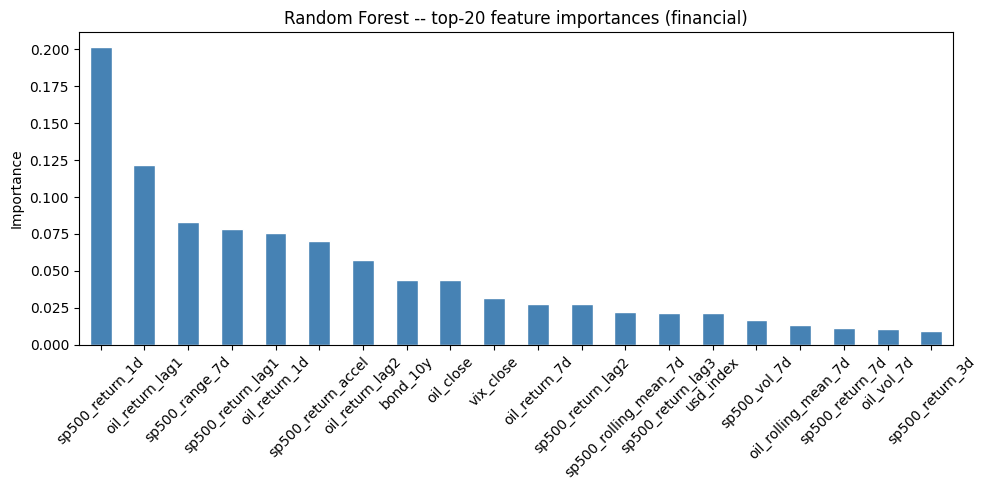

In [10]:
fi = pd.Series(rf_model.feature_importances_, index=FIN_COLS).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
fi.head(20).plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Random Forest -- top-20 feature importances (financial)")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", labelrotation=45)
plt.tight_layout()
plt.show()

## 8. Model 3 — Neural Network (MLP)

In [ ]:
nn_factory = lambda: MLPRegressor(
    hidden_layer_sizes=(32, 16), activation="relu", solver="adam",
    learning_rate_init=1e-3, max_iter=1000,
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=30, random_state=RANDOM_STATE,
)

print("=== Neural Network (MLP) -- CV ===")
nn_cv = cv_evaluate(nn_factory, folds, X_tv, y_tv, scale=True)
nn_cv.round(4)

=== Neural Network (MLP) -- CV ===


ValueError: The validation set is too small. Increase 'validation_fraction' or the size of your dataset.

: 

In [ ]:
nn_model, nn_pred, nn_test = final_eval(nn_factory, X_tv, y_tv, X_test, y_test, scale=True)
print("Neural Network -- Test set:")
for k, v in nn_test.items():
    print(f"  {k}: {v:.4f}")

## 9. Model comparison

In [ ]:
cv_summary = pd.DataFrame({
    "Linear Regression": lr_cv.loc["Mean"],
    "Random Forest"    : rf_cv.loc["Mean"],
    "Neural Network"   : nn_cv.loc["Mean"],
}).T.round(4)
print("CV performance (mean across folds):")
display(cv_summary)

In [ ]:
test_summary = pd.DataFrame({
    "Linear Regression": lr_test,
    "Random Forest"    : rf_test,
    "Neural Network"   : nn_test,
}).T.round(4)
print("Test set performance:")
display(test_summary)

In [ ]:
test_dates = df_test["date"].values
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, (label, pred, col) in zip(axes, [
    ("Linear Regression", lr_pred, colors[0]),
    ("Random Forest",     rf_pred, colors[1]),
    ("Neural Network",    nn_pred, colors[2]),
]):
    ax.plot(test_dates, y_test, label="Actual",    color="black", linewidth=1.5)
    ax.plot(test_dates, pred,   label="Predicted", color=col,    linewidth=1.5, linestyle="--")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle=":")
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel("delta Trump prob")
    ax.legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("Date")
fig.suptitle("Test-set predictions vs actuals\nDaily delta Polymarket Trump probability -- Financial features only", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
metrics = ["MAE", "RMSE", "Dir. Accuracy", "R2"]
models  = ["Linear Regression", "Random Forest", "Neural Network"]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, metric in zip(axes, metrics):
    vals = [test_summary.loc[m, metric] for m in models]
    bars = ax.bar(models, vals, color=colors, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=20, ha="right", fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Test-set metric comparison -- Financial-only models", fontsize=12)
plt.tight_layout()
plt.show()